# DSN Mart Sales Prediction — From Business Question to Submission
**Author:** Haleem Akintayo &nbsp;|&nbsp; **Competition:** DSN AI Bootcamp Qualification Hackathon &nbsp;|&nbsp; **Metric:** RMSE on `total_sales` (lower is better)

---
### Executive summary
* **Core insight.** Revenue = price × units, and units are set almost entirely by the **store**. Units per product by format:

  | Format | Units per product |
  |---|---|
  | Flagship hypermarket | ~26 |
  | Standard supermarkets | 16–17 |
  | Superstore | ~14 |
  | Corner shops | ~2.4 |

  That is an 11× range.
* **Signal vs noise.** Once the store effect is removed, product attributes show no reliable link with units: weight, shelf visibility, category and fat content all have |Spearman ρ| ≤ 0.015. What remains is roughly ±45% multiplicative noise.
* **Model.** Store throughput × denoised price × a 4-parameter price curve, which is **14 parameters in total**.
  * Cross-validated RMSE is **1069.96 ± 0.40** (5-fold × 3 repeats, leak-free).
  * It beats a LightGBM on 20 engineered features (our earlier approach) by **~14 RMSE** (95% CI 8.7 to 19.8).
  * It sits within about 1 RMSE of the estimated achievable limit (~1069) for this data.
* **Public leaderboard:** 1069.75.
* **Leaderboard caveat.** The public board scores only ~850 rows. On a board that size, an identical model's score moves by **±37 RMSE** by chance alone, so every modelling decision here was made on cross-validation, never on the public score.

---
### Structure of this notebook
The notebook follows the five stages the hackathon asks for.

| Stage | Sections | Question answered |
|---|---|---|
| **Understand** | 1–2 | What is being predicted, for whom, and how is it scored? Is the data trustworthy? |
| **Analyse** | 3 | What actually drives sales? What is noise? |
| **Model** | 4–7 | Which modelling choices help *under honest validation*, and how close to the achievable limit are we? |
| **Predict** | 8 | Final predictions with sanity checks. |
| **Communicate** | 9 | What DSN Mart should do with this, limitations, and next steps. |


# UNDERSTAND
## 1. Problem framing
**Business question.** DSN Mart runs stores ranging from corner shops to flagship hypermarkets across Nigeria. For a given *(product, store)* pair, how much revenue will that product generate? Good answers support stock planning, pricing and store investment decisions.

**ML task.** Tabular regression. Each row is one product in one store; the target is `total_sales` (₦).

**Metric.** Root Mean Squared Error. Because errors are squared, RMSE is dominated by the *largest* sales values — so the high-volume stores and expensive products matter most, and a model must be well calibrated in the right tail.

**What the columns mean**

| Column | Level | Description |
|---|---|---|
| `product_code` | product | SKU identifier |
| `product_weight_kg`, `fat_content`, `product_category` | product | Product attributes |
| `shelf_visibility` | product × store | Share of display area given to the product |
| `product_price` | product × store | Listed price (₦) |
| `store_code`, `store_age_years`, `store_size`, `store_location_tier`, `store_format` | store | Outlet attributes |
| `total_sales` | product × store | **Target** — revenue (₦) |

A useful identity to keep in mind throughout: **revenue = price × units sold**. Price is given, so the real unknown is *how many units* a product sells in a store.

In [1]:
import os, glob, time, warnings, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import sklearn
try:
    from catboost import CatBoostRegressor
except ImportError:                      # Colab does not ship CatBoost; Kaggle does
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'catboost'], check=True)
    from catboost import CatBoostRegressor
from sklearn.model_selection import KFold, train_test_split, cross_val_predict
from sklearn.metrics import roc_auc_score
from scipy.optimize import nnls

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda v: f'{v:,.3f}')
sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 100, 'axes.titleweight': 'bold', 'axes.spines.top': False, 'axes.spines.right': False})
PALETTE = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3', '#937860']

CFG = dict(
    seed=42,
    n_splits=5,
    n_repeats=3,              # repeated K-fold: every experiment is scored on the same 3 x 5 splits
)
TARGET, ID_COL = 'total_sales', 'id'
np.random.seed(CFG['seed'])
print(f"python {platform.python_version()} | pandas {pd.__version__} | sklearn {sklearn.__version__} | lightgbm {lgb.__version__}")

python 3.12.3 | pandas 3.0.2 | sklearn 1.8.0 | lightgbm 4.7.0


In [2]:
# Locate the data (works locally, on Colab and on Kaggle without edits)
candidates = ['.', 'data', '/content', *glob.glob('/kaggle/input/*')]
DATA_DIR = next((d for d in candidates if os.path.exists(os.path.join(d, 'train.csv'))), None)
assert DATA_DIR is not None, 'train.csv / test.csv not found - put them next to this notebook'

train_raw = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))
test_raw = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))
print(f'Train: {train_raw.shape} | Test: {test_raw.shape}  (data from: {DATA_DIR})')
train_raw.head()

Train: (6818, 13) | Test: (1705, 12)  (data from: .)


,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
0,row_00000,PRD-PRFP9S,14.252,Low Fat,0.027,Frozen Foods,81.370,STORE-AGY,45,Large,Tier_3,Standard Supermarket,"1,764.980"
1,row_00001,PRD-PXXK71,7.698,Low Fat,0.072,HEALTH AND HYGIENE,42.050,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.130
2,row_00002,PRD-V5MOIJ,14.264,Regular,0.042,Canned,41.350,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.850
3,row_00003,PRD-UN5Z3J,NaN,Regular,0.045,soft drinks,174.350,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,"5,595.720"
4,row_00004,PRD-6RDQYB,10.338,Regular,0.012,meat,203.060,STORE-9RG,28,Small,Tier_2,Standard Supermarket,"2,375.360"


## 2. Data quality audit


In [3]:
overview = pd.DataFrame({
    'dtype': train_raw.dtypes.astype(str),
    'missing_train_%': train_raw.isna().mean().mul(100).round(2),
    'missing_test_%': test_raw.isna().mean().mul(100).round(2),
    'n_unique': train_raw.nunique(),
})
display(overview)

both = pd.concat([train_raw, test_raw], ignore_index=True)
store_cols = ['store_age_years', 'store_size', 'store_location_tier', 'store_format']
checks = {
    'duplicate rows': train_raw.duplicated().sum(),
    'duplicate (product, store) pairs in train+test': both.duplicated(['product_code', 'store_code']).sum(),
    'stores with non-constant attributes': int((both.groupby('store_code')[store_cols].nunique(dropna=False) > 1).any(axis=1).sum()),
    'test rows whose product appears in train (%)': round(test_raw['product_code'].isin(train_raw['product_code']).mean() * 100, 1),
    'test rows whose store appears in train (%)': round(test_raw['store_code'].isin(train_raw['store_code']).mean() * 100, 1),
    'number of stores': both['store_code'].nunique(),
    'number of products': both['product_code'].nunique(),
    'rows with shelf_visibility == 0': int((both['shelf_visibility'] == 0).sum()),
}
pd.Series(checks, name='value').to_frame()

,dtype,missing_train_%,missing_test_%,n_unique
fat_content,str,0.000,0.000,2
id,str,0.000,0.000,6818
product_category,str,0.000,0.000,48
product_code,str,0.000,0.000,1555
product_price,float64,0.000,0.000,5818
product_weight_kg,float64,17.970,17.950,4675
shelf_visibility,float64,0.000,0.000,1732
store_age_years,int64,0.000,0.000,9
store_code,str,0.000,0.000,10
store_format,str,0.000,0.000,4


,value
duplicate rows,0.000
"duplicate (product, store) pairs in train+test",0.000
stores with non-constant attributes,0.000
test rows whose product appears in train (%),99.600
test rows whose store appears in train (%),100.000
number of stores,10.000
number of products,"1,559.000"
rows with shelf_visibility == 0,526.000


In [4]:
# Categorical spellings
for col in ['fat_content', 'store_size', 'store_location_tier', 'store_format']:
    print(f'{col}:', dict(both[col].value_counts(dropna=False)))
print('\nproduct_category raw levels:', both['product_category'].nunique(),
      '-> after strip + title-case:', both['product_category'].str.strip().str.title().nunique())
print('\nstore_size missing by store:')
print(both.groupby('store_code')['store_size'].apply(lambda s: s.isna().mean()).round(2).to_dict())

fat_content: {'Low Fat': np.int64(5517), 'Regular': np.int64(3006)}
store_size: {'Medium': np.int64(2793), nan: np.int64(2410), 'Small': np.int64(2388), 'Large': np.int64(932)}
store_location_tier: {'Tier_3': np.int64(3350), 'Tier_2': np.int64(2785), 'Tier_1': np.int64(2388)}
store_format: {'Standard Supermarket': np.int64(5577), 'Corner Shop': np.int64(1083), 'Flagship Hypermarket': np.int64(935), 'Superstore': np.int64(928)}

product_category raw levels: 48 -> after strip + title-case: 16

store_size missing by store:
{'STORE-7WS': 0.0, 'STORE-89Z': 0.0, 'STORE-9RG': 0.0, 'STORE-AGY': 0.0, 'STORE-DKU': 1.0, 'STORE-HL7': 0.0, 'STORE-JOR': 1.0, 'STORE-OYG': 1.0, 'STORE-T5G': 0.0, 'STORE-YLW': 0.0}


In [5]:
# Are product attributes constant within a product? (they should be, in a clean catalogue)
g = both.groupby('product_code')
within = pd.DataFrame({
    'price_std_within_product': g['product_price'].std(),
    'weight_std_within_product': g['product_weight_kg'].std(),
    'visibility_std_within_product': g['shelf_visibility'].std(),
    'rows_per_product': g.size(),
}).describe().T[['mean', '50%', 'max']]
display(within)
print('Products whose fat_content label varies across stores:', int((g['fat_content'].nunique() > 1).sum()))

,mean,50%,max
price_std_within_product,2.644,2.449,7.274
weight_std_within_product,0.211,0.198,0.722
visibility_std_within_product,0.019,0.011,0.115
rows_per_product,5.467,5.000,10.000


Products whose fat_content label varies across stores: 0


### 2.2 Audit findings and cleaning decisions
| Finding | Decision | Reason |
|---|---|---|
| `product_category` has ~48 spellings of 16 categories (case variants) | strip + title-case | same category, different casing |
| `fat_content` already uses two clean labels, but non-food categories carry a fat label | map non-food categories to `Non-Edible` | fat content is meaningless for household / hygiene items |
| ~18% of `product_weight_kg` missing | fill with product median, then category median; keep a missing flag | weight is a product property |
| `shelf_visibility == 0` for a few hundred rows | treat as missing → product mean; keep a flag | a stocked product cannot have zero display space |
| `store_size` missing for **entire stores** | explicit `Unknown` level | the store is still identified by `store_code`; imputing a size would invent information |
| **`product_price` varies slightly for the same product across rows** (std ≈ ₦2–3) | keep the row price **and** add the product's mean price `p_mean` | if this is measurement noise, averaging over a product's rows gives a cleaner price signal (tested in Section 4) |
| Each (product, store) pair appears once; all test stores and >99% of test products are seen in train | — | the task is interpolation within a known catalogue |

In [6]:
NON_EDIBLE = ['Household', 'Health And Hygiene', 'Others']
FAT_MAP = {'low fat': 'Low Fat', 'lf': 'Low Fat', 'regular': 'Regular', 'reg': 'Regular'}

def clean(train, test):
    df = pd.concat([train.assign(_split='train'), test.assign(_split='test')], ignore_index=True)
    df['product_category'] = df['product_category'].astype(str).str.strip().str.title()
    df['fat_content'] = df['fat_content'].astype(str).str.strip().str.lower().map(FAT_MAP).fillna('Unknown')
    df.loc[df['product_category'].isin(NON_EDIBLE), 'fat_content'] = 'Non-Edible'

    df['weight_was_missing'] = df['product_weight_kg'].isna().astype(int)
    df['product_weight_kg'] = (df['product_weight_kg']
                               .fillna(df.groupby('product_code')['product_weight_kg'].transform('median'))
                               .fillna(df.groupby('product_category')['product_weight_kg'].transform('median')))

    df['visibility_was_zero'] = (df['shelf_visibility'] == 0).astype(int)
    vis = df['shelf_visibility'].replace(0, np.nan)
    df['shelf_visibility'] = vis.fillna(vis.groupby(df['product_code']).transform('mean')).fillna(vis.median())

    df['store_size'] = df['store_size'].fillna('Unknown')
    return df

df = clean(train_raw, test_raw)
print('Categories after cleaning:', sorted(df['product_category'].unique()))
print(df['fat_content'].value_counts().to_dict())
print('Missing values left (excluding target):', int(df.drop(columns=TARGET).isna().sum().sum()))

Categories after cleaning: ['Baking Goods', 'Breads', 'Breakfast', 'Canned', 'Dairy', 'Frozen Foods', 'Fruits And Vegetables', 'Hard Drinks', 'Health And Hygiene', 'Household', 'Meat', 'Others', 'Seafood', 'Snack Foods', 'Soft Drinks', 'Starchy Foods']
{'Low Fat': 3918, 'Regular': 3006, 'Non-Edible': 1599}
Missing values left (excluding target): 0


# ANALYSE
## 3. Exploratory data analysis
Each plot answers one question. Because *revenue = price × units*, most of the analysis looks at **units** (`total_sales / product_price`) and at **relative units** — units divided by the store's average units — which removes the store effect and lets us ask whether anything *else* matters.

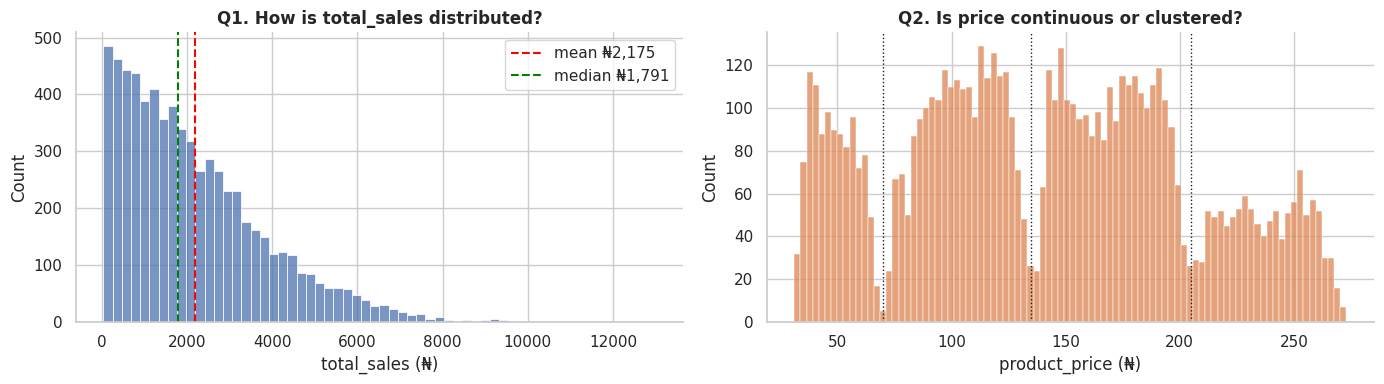

Target skew: 1.15 | share of total squared deviation from the top 10% of sales: 51%


In [7]:
eda = df[df['_split'] == 'train'].copy()
eda['units'] = eda[TARGET] / eda['product_price']
eda['rel_units'] = eda['units'] / eda.groupby('store_code')['units'].transform('mean')

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(eda[TARGET], bins=60, ax=ax[0], color=PALETTE[0])
ax[0].axvline(eda[TARGET].mean(), color='red', ls='--', label=f"mean ₦{eda[TARGET].mean():,.0f}")
ax[0].axvline(eda[TARGET].median(), color='green', ls='--', label=f"median ₦{eda[TARGET].median():,.0f}")
ax[0].set(title='Q1. How is total_sales distributed?', xlabel='total_sales (₦)'); ax[0].legend()
sns.histplot(eda['product_price'], bins=90, ax=ax[1], color=PALETTE[1])
for b in [70, 135, 205]: ax[1].axvline(b, color='k', ls=':', lw=1)
ax[1].set(title='Q2. Is price continuous or clustered?', xlabel='product_price (₦)')
plt.tight_layout(); plt.show()
print(f"Target skew: {eda[TARGET].skew():.2f} | share of total squared deviation from the top 10% of sales: "
      f"{((eda[TARGET]-eda[TARGET].mean())**2)[eda[TARGET] > eda[TARGET].quantile(.9)].sum() / ((eda[TARGET]-eda[TARGET].mean())**2).sum():.0%}")

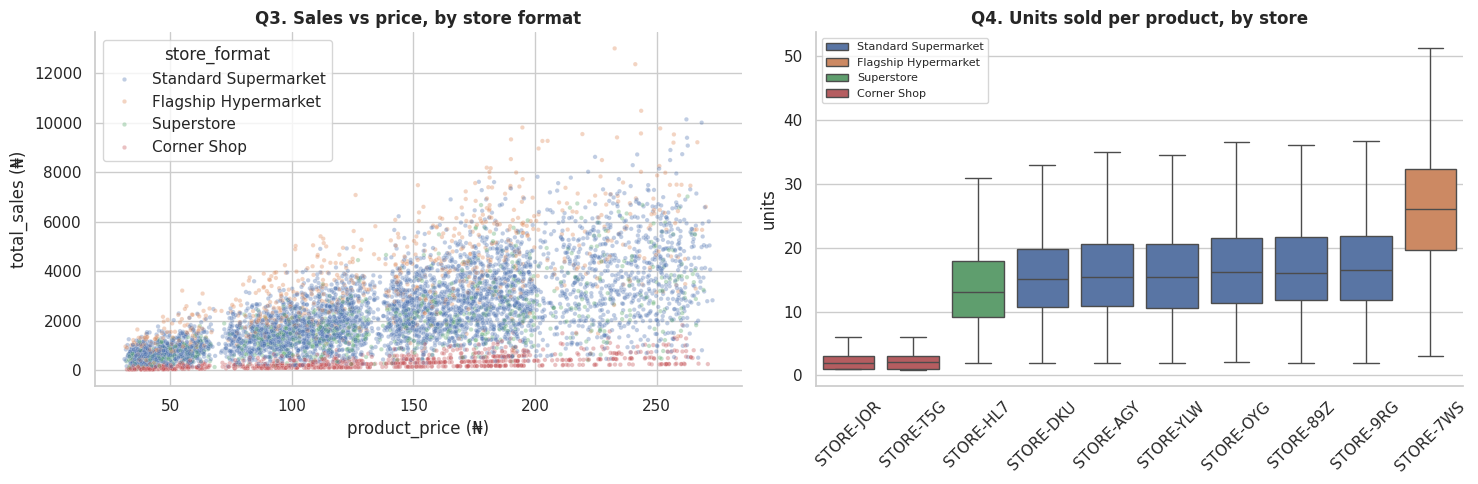

,,,,,rows,mean_units,mean_sales,revenue_share_%
store_code,store_format,store_size,store_location_tier,store_age_years,,,,
STORE-JOR,Corner Shop,Unknown,Tier_3,34,439,2.388,334.435,0.990
STORE-T5G,Corner Shop,Small,Tier_1,47,427,2.462,338.327,0.974
STORE-HL7,Superstore,Medium,Tier_3,23,742,13.854,"1,971.662",9.867
STORE-DKU,Standard Supermarket,Unknown,Tier_2,30,736,15.658,"2,177.136",10.807
STORE-AGY,Standard Supermarket,Large,Tier_3,45,748,15.953,"2,254.890",11.375
STORE-YLW,Standard Supermarket,Small,Tier_1,35,754,16.099,"2,253.951",11.462
STORE-OYG,Standard Supermarket,Unknown,Tier_2,25,744,16.655,"2,365.834",11.871
STORE-89Z,Standard Supermarket,Medium,Tier_1,33,728,16.823,"2,365.927",11.616
STORE-9RG,Standard Supermarket,Small,Tier_2,28,752,17.146,"2,479.168",12.573


In [8]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.scatterplot(data=eda, x='product_price', y=TARGET, hue='store_format', alpha=.35, s=10, ax=ax[0], palette=PALETTE[:4])
ax[0].set(title='Q3. Sales vs price, by store format', xlabel='product_price (₦)', ylabel='total_sales (₦)')
order = eda.groupby('store_code')['units'].mean().sort_values().index
sns.boxplot(data=eda, x='store_code', y='units', order=order, hue='store_format', dodge=False,
            showfliers=False, ax=ax[1], palette=PALETTE[:4])
ax[1].set(title='Q4. Units sold per product, by store', xlabel=''); ax[1].tick_params(axis='x', rotation=45)
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

store_profile = (eda.groupby(['store_code', 'store_format', 'store_size', 'store_location_tier', 'store_age_years'], observed=True)
                   .agg(rows=(TARGET, 'size'), mean_units=('units', 'mean'), mean_sales=(TARGET, 'mean'), total_revenue=(TARGET, 'sum'))
                   .sort_values('mean_units'))
store_profile['revenue_share_%'] = store_profile['total_revenue'] / store_profile['total_revenue'].sum() * 100
store_profile.drop(columns='total_revenue')

,mean_rel_units,std_rel_units,std_sales
product_price,,,
"(31.108999999999998, 83.752]",0.995,0.467,574.947
"(83.752, 117.848]",0.988,0.444,944.670
"(117.848, 158.83]",0.992,0.443,"1,267.564"
"(158.83, 194.228]",1.030,0.470,"1,678.711"
"(194.228, 273.04]",0.995,0.454,"2,066.913"


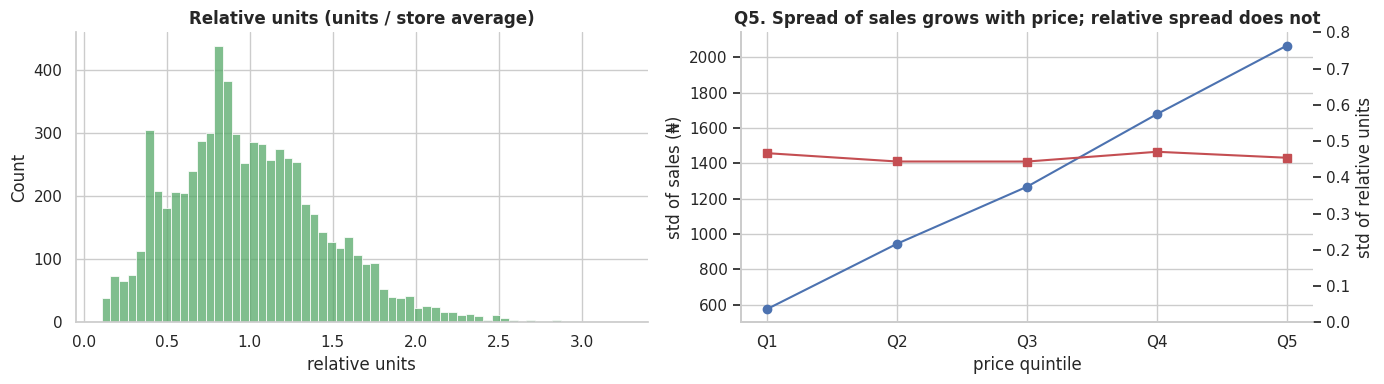

In [9]:
# Q5. Does the noise grow with the size of the sale? (shape of the error, not just its size)
q = pd.qcut(eda['product_price'], 5)
noise = eda.groupby(q, observed=True).agg(mean_rel_units=('rel_units', 'mean'), std_rel_units=('rel_units', 'std'),
                                          std_sales=(TARGET, 'std'))
display(noise)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(eda['rel_units'], bins=60, ax=ax[0], color=PALETTE[2])
ax[0].set(title='Relative units (units / store average)', xlabel='relative units')
ax[1].plot(range(5), noise['std_sales'], marker='o', label='std of sales (₦)')
ax[1].set_xticks(range(5)); ax[1].set_xticklabels([f'Q{i+1}' for i in range(5)])
ax[1].set(title='Q5. Spread of sales grows with price; relative spread does not', xlabel='price quintile', ylabel='std of sales (₦)')
ax2 = ax[1].twinx(); ax2.plot(range(5), noise['std_rel_units'], marker='s', color=PALETTE[3], label='std of relative units')
ax2.set_ylim(0, .8); ax2.set_ylabel('std of relative units'); ax2.grid(False)
plt.tight_layout(); plt.show()

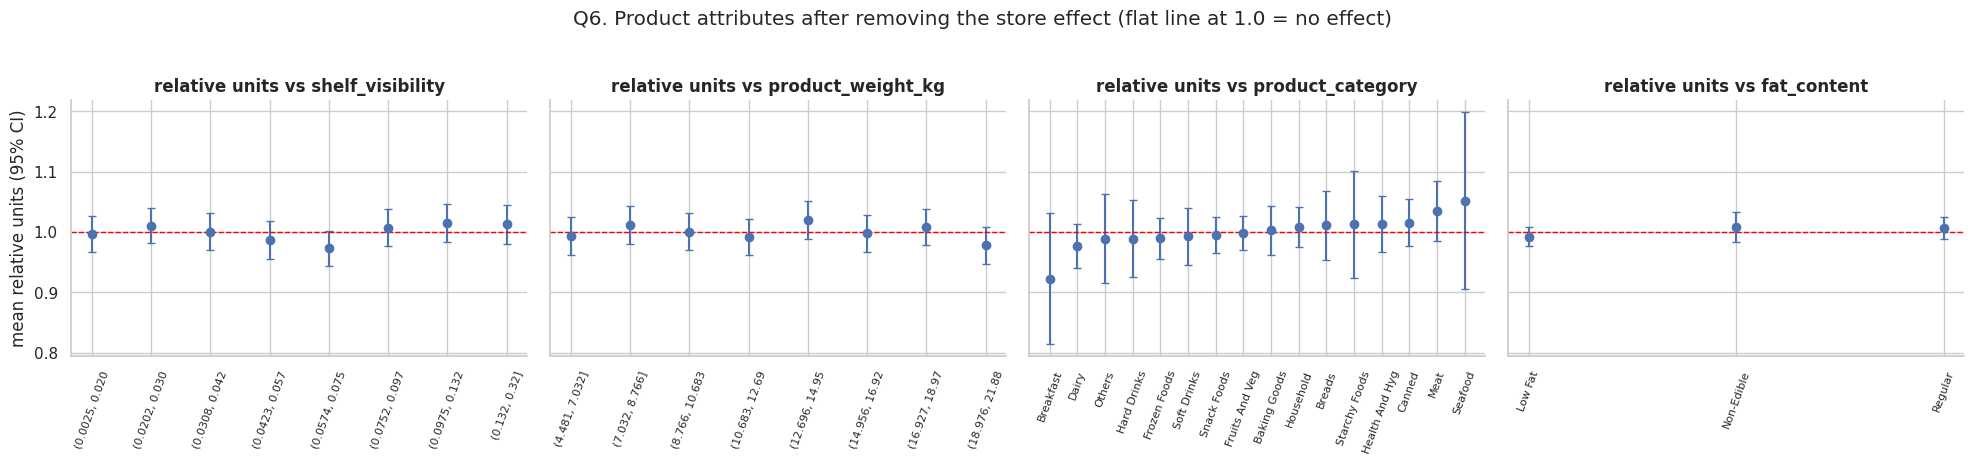

Spearman correlation with relative units:
{'shelf_visibility': -0.003, 'product_weight_kg': -0.003, 'product_price': 0.015}


In [10]:
# Q6. Once store and price are accounted for, do product attributes move units?
def binned_effect(col, bins=None):
    x = pd.qcut(eda[col], 8, duplicates='drop') if bins is None else eda[col]
    t = eda.groupby(x, observed=True)['rel_units'].agg(['mean', 'std', 'size'])
    t['ci95'] = 1.96 * t['std'] / np.sqrt(t['size'])
    return t

fig, ax = plt.subplots(1, 4, figsize=(20, 4.5), sharey=True)
for a, col in zip(ax, ['shelf_visibility', 'product_weight_kg', 'product_category', 'fat_content']):
    t = binned_effect(col, bins=None if eda[col].dtype.kind == 'f' else 'cat')
    if col == 'product_category': t = t.sort_values('mean')
    a.errorbar(range(len(t)), t['mean'], yerr=t['ci95'], fmt='o', capsize=3, color=PALETTE[0])
    a.axhline(1, color='red', ls='--', lw=1)
    a.set_xticks(range(len(t))); a.set_xticklabels([str(i)[:14] for i in t.index], rotation=70, fontsize=8)
    a.set_title(f'relative units vs {col}')
ax[0].set_ylabel('mean relative units (95% CI)')
plt.suptitle('Q6. Product attributes after removing the store effect (flat line at 1.0 = no effect)', y=1.03)
plt.tight_layout(); plt.show()

print('Spearman correlation with relative units:')
print(eda[['shelf_visibility', 'product_weight_kg', 'product_price']].corrwith(eda['rel_units'], method='spearman').round(3).to_dict())

In [11]:
# Q7. Is there a product-level effect at all? Variance decomposition of relative units.
# If products differed in popularity, product means would vary MORE than pure noise would make them vary.
g = eda.groupby('product_code')['rel_units']
within_var = ((eda['rel_units'] - g.transform('mean')) ** 2).sum() / (len(eda) - g.ngroups)
stats = g.agg(['mean', 'count'])
observed_between = np.average((stats['mean'] - eda['rel_units'].mean()) ** 2, weights=stats['count'])
expected_from_noise = within_var * g.ngroups / len(eda)   # = within_var / average rows per product
print(f'Within-product variance of relative units : {within_var:.4f}')
print(f'Observed variance of product means        : {observed_between:.4f}')
print(f'Expected from noise alone                 : {expected_from_noise:.4f}')
print(f'Implied true product variance             : {max(observed_between - expected_from_noise, 0):.4f} '
      f'(~{np.sqrt(max(observed_between - expected_from_noise, 0))*100:.1f}% typical effect, estimated from only ~{len(eda)/g.ngroups:.1f} rows per product)')

Within-product variance of relative units : 0.2020
Observed variance of product means        : 0.0518
Expected from noise alone                 : 0.0461
Implied true product variance             : 0.0058 (~7.6% typical effect, estimated from only ~4.4 rows per product)


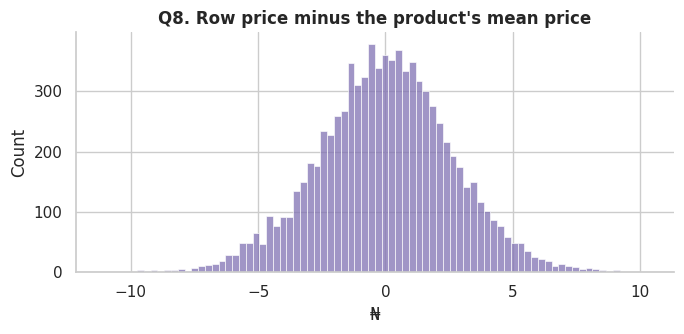

std of price deviation: ₦2.65 (vs overall price std ₦62.3)


In [12]:
# Q8. How noisy is the listed price within a product?
dev = both.assign(p_mean=both.groupby('product_code')['product_price'].transform('mean'))
dev = dev['product_price'] - dev['p_mean']
fig, ax = plt.subplots(figsize=(7, 3.5))
sns.histplot(dev, bins=80, ax=ax, color=PALETTE[4]); ax.set(title='Q8. Row price minus the product\'s mean price', xlabel='₦')
plt.tight_layout(); plt.show()
print(f'std of price deviation: ₦{dev.std():.2f} (vs overall price std ₦{both.product_price.std():.1f})')

In [13]:
# Q9. Do train and test come from the same distribution? (adversarial validation)
adv_cols = ['product_weight_kg', 'shelf_visibility', 'product_price', 'store_age_years', 'fat_content',
            'product_category', 'store_code', 'store_size', 'store_location_tier', 'store_format']
adv_X = df[adv_cols].copy()
for c in adv_X.select_dtypes(exclude='number').columns: adv_X[c] = adv_X[c].astype('category')
adv_y = (df['_split'] == 'test').astype(int)
adv_p = cross_val_predict(lgb.LGBMClassifier(n_estimators=200, verbose=-1, random_state=CFG['seed']),
                          adv_X, adv_y, cv=5, method='predict_proba')[:, 1]
print(f'Adversarial AUC: {roc_auc_score(adv_y, adv_p):.3f}  (0.5 = indistinguishable -> shuffled K-fold mirrors the test set)')

Adversarial AUC: 0.511  (0.5 = indistinguishable -> shuffled K-fold mirrors the test set)


### 3.1 EDA key findings
1. **The target is right-skewed** (skew 1.15). The top 10% of sales rows account for **51%** of the total squared deviation, so RMSE is decided mainly by large stores and expensive products.
2. **Price comes in four clusters**, with gaps near ₦70, ₦135 and ₦205 (Q2).
   * The same product also shows slightly different prices across rows: the within-product standard deviation is ₦2.65 (Q8).
   * Nothing explains that variation, so we treat it as noise and use the product's mean price `p_mean` as a cleaner signal.
3. **Store format drives volume** (Q3, Q4). Corner shops sell ~2.4 units per product and the flagship hypermarket ~26.4.
   * Standard supermarkets all sell **15.7–17.1 units**, whatever their tier (1–3) or size (small–large).
   * In this sample, format matters while location tier and size barely do.
4. **The noise is multiplicative** (Q5). The spread of *relative* units stays at about 0.44–0.47 in every price quintile, while the spread of sales grows ~3.6× from the cheapest to the most expensive quintile.
   * Errors therefore scale with the size of the sale.
   * The correction should be modelled as a *ratio* and weighted so the loss stays on the sales scale.
5. **Product attributes are flat** once the store effect is removed (Q6). Every 95% interval overlaps 1.0.
   * The variance decomposition (Q7) points the same way. Product means vary only slightly more than pure noise predicts (0.052 vs 0.046).
   * That implies at most a ~7.6% product effect, estimated from only ~4.4 rows per product, which is too little data to exploit reliably.
6. **Train and test look alike.** The adversarial AUC is 0.511, so shuffled K-fold is a faithful stand-in for the test set.

**Modelling hypothesis coming out of the EDA:** predicted sales ≈ *store throughput* × *(denoised) price* × *a small correction*. The model should be built around that structure rather than asked to rediscover it from dozens of weak features.

# MODEL
## 4. Validation design
Mistakes in validation are the most common reason public-leaderboard gains do not survive to the private board. The rules used here:

1. **Repeated K-fold** (5 folds × 3 repeats, identical splits for every experiment) — adversarial AUC ≈ 0.5, so shuffled folds mirror the test set.
2. **Everything learned from the target is learned inside the fold**: store throughput, target encodings, blend weights.
3. **Early stopping never looks at the validation fold.** The number of trees is picked on an *inner* 15% split of the training fold; the model is then refit on the whole training fold with that number. (Stopping on the validation fold makes CV look better than it is.)
4. **No post-hoc multipliers or weights tuned on the scored predictions.**
5. **Decisions use paired comparisons**: two models are compared on the same rows and the uncertainty of the difference is bootstrapped (Section 5.2).

### 4.1 Features
Two feature families are built, so that the experiments can test whether "more features" helps.

In [14]:
PRICE_BINS = [0, 70, 135, 205, np.inf]           # read off the Q2 histogram

# Core features (motivated by the EDA)
df['p_mean'] = df.groupby('product_code')['product_price'].transform('mean')   # denoised price (no target used)
df['p_dev'] = df['product_price'] - df['p_mean']
df['price_band'] = pd.cut(df['product_price'], PRICE_BINS, labels=False).astype(int)

# Broader "retail" features (used in earlier versions; kept to test whether they help)
df['price_per_kg'] = df['product_price'] / df['product_weight_kg']
df['price_to_store_mean'] = df['product_price'] / df.groupby('store_code')['product_price'].transform('mean')
df['price_to_cat_mean'] = df['product_price'] / df.groupby('product_category')['product_price'].transform('mean')
df['vis_to_product_mean'] = df['shelf_visibility'] / df.groupby('product_code')['shelf_visibility'].transform('mean')
df['shelf_revenue_proxy'] = df['shelf_visibility'] * df['product_price']
df['product_store_count'] = df.groupby('product_code')['store_code'].transform('nunique')
df['format_tier'] = df['store_format'] + '_' + df['store_location_tier']

CAT_COLS = ['product_code', 'fat_content', 'product_category', 'store_code', 'store_size',
            'store_location_tier', 'store_format', 'format_tier']
for c in CAT_COLS: df[c] = df[c].astype('category')

train_df = df[df['_split'] == 'train'].drop(columns='_split').reset_index(drop=True)
test_df = df[df['_split'] == 'test'].drop(columns=['_split', TARGET]).reset_index(drop=True)
y = train_df[TARGET].values

FEATS_RAW = ['product_price', 'product_weight_kg', 'shelf_visibility', 'fat_content', 'product_category',
             'store_code', 'store_size', 'store_location_tier', 'store_format', 'store_age_years']
FEATS_RICH = FEATS_RAW + ['weight_was_missing', 'visibility_was_zero', 'price_band', 'price_per_kg',
                          'price_to_store_mean', 'price_to_cat_mean', 'vis_to_product_mean',
                          'shelf_revenue_proxy', 'product_store_count', 'format_tier']
print(f'train {train_df.shape} | test {test_df.shape} | raw feats {len(FEATS_RAW)} | rich feats {len(FEATS_RICH)}')

train (6818, 25) | test (1705, 24) | raw feats 10 | rich feats 20


### 4.2 The cross-validation engine
Every model is written as a small `fit(train_fold, y_fold, [frames to predict], seed)` function, and `evaluate` runs it on the shared folds. This keeps experiments comparable and makes leakage structurally hard.

In [15]:
FOLDS = [list(KFold(CFG['n_splits'], shuffle=True, random_state=CFG['seed'] + r).split(train_df))
         for r in range(CFG['n_repeats'])]
RESULTS = {}

def rmse(a, b):
    return float(np.sqrt(np.mean((np.asarray(a) - np.asarray(b)) ** 2)))

def evaluate(name, fit, seeds=(CFG['seed'],), desc=''):
    '''Run `fit` on every fold of every repeat. Returns per-repeat OOF predictions, CV scores and averaged test predictions.'''
    t0 = time.time()
    oofs = np.zeros((len(FOLDS), len(y)))
    test_pred, n = np.zeros(len(test_df)), 0
    for seed in seeds:
        for r, split in enumerate(FOLDS):
            for tr_idx, va_idx in split:
                p_va, p_te = fit(train_df.iloc[tr_idx], y[tr_idx], [train_df.iloc[va_idx], test_df], seed=seed + r)
                oofs[r, va_idx] += p_va / len(seeds)
                test_pred += p_te; n += 1
    scores = [rmse(y, o) for o in oofs]
    RESULTS[name] = dict(name=name, desc=desc, cv_mean=np.mean(scores), cv_std=np.std(scores),
                         oofs=oofs, test=test_pred / n, minutes=(time.time() - t0) / 60)
    print(f"{name:<42} CV {np.mean(scores):8.2f} ± {np.std(scores):.2f}   ({RESULTS[name]['minutes']:.1f} min)")
    return RESULTS[name]

# ---------- building blocks, all fitted on the training fold only ----------
def store_throughput(t, yt, price_col='p_mean', how='units'):
    '''Units per product for each store. "units": mean of y/price (efficient when noise is multiplicative).
    "ols": least-squares slope of y on price through the origin.'''
    if how == 'units':
        return pd.Series(yt / t[price_col].values, index=t.index).groupby(t['store_code'], observed=True).mean()
    p, out = t[price_col].values, {}
    for s in t['store_code'].unique():
        m = (t['store_code'] == s).values
        out[s] = (p[m] @ yt[m]) / (p[m] @ p[m])
    return pd.Series(out)

def baseline(frame, b, price_col='p_mean'):
    return frame['store_code'].map(b).astype(float).values * frame[price_col].values

def lgb_inner_es(X, target, weight, params, seed):
    '''Choose n_estimators on an inner 15% split of the TRAINING fold, then refit on the full training fold.'''
    idx_fit, idx_es = train_test_split(np.arange(len(X)), test_size=0.15, random_state=seed)
    w = (lambda i: None) if weight is None else (lambda i: weight[i])
    m = lgb.LGBMRegressor(**params, n_estimators=5000, random_state=seed, verbose=-1)
    m.fit(X.iloc[idx_fit], target[idx_fit], sample_weight=w(idx_fit),
          eval_set=[(X.iloc[idx_es], target[idx_es])], eval_sample_weight=None if weight is None else [w(idx_es)],
          callbacks=[lgb.early_stopping(200, verbose=False)])
    n_best = max(int(m.best_iteration_ * 1.1), 20)          # slightly more trees: refit uses ~18% more data
    return lgb.LGBMRegressor(**params, n_estimators=n_best, random_state=seed, verbose=-1).fit(X, target, sample_weight=weight)

def cat_inner_es(X, target, weight, params, cat_features, seed):
    idx_fit, idx_es = train_test_split(np.arange(len(X)), test_size=0.15, random_state=seed)
    m = CatBoostRegressor(**params, iterations=3000, random_seed=seed, verbose=0, cat_features=cat_features)
    m.fit(X.iloc[idx_fit], target[idx_fit], sample_weight=weight[idx_fit],
          eval_set=(X.iloc[idx_es], target[idx_es]), early_stopping_rounds=200)
    n_best = max(int(m.get_best_iteration() * 1.1), 20)
    return CatBoostRegressor(**params, iterations=n_best, random_seed=seed, verbose=0,
                             cat_features=cat_features).fit(X, target, sample_weight=weight)

## 5. Experiments
### 5.1 Baselines and controlled experiments
The experiments are grouped by the question they answer. **B** = rule-based baselines, **D** = "direct" gradient boosting on `total_sales` (the approach of earlier versions), **P** = models built on the physical baseline *store throughput × price*.

In [16]:
# ---------------- B: rule-based baselines ----------------
evaluate('B1 global mean', lambda t, yt, vs, seed: [np.full(len(v), yt.mean()) for v in vs],
         desc='predict the training mean everywhere')
evaluate('B2 store mean sales', lambda t, yt, vs, seed: [v['store_code'].map(pd.Series(yt, index=t.index).groupby(t['store_code'], observed=True).mean()).astype(float).values for v in vs],
         desc='average sales of the store')
evaluate('B3 store slope (OLS) x row price', lambda t, yt, vs, seed: [baseline(v, store_throughput(t, yt, 'product_price', 'ols'), 'product_price') for v in vs],
         desc='least-squares units per store x listed price')
evaluate('B4 store units x row price', lambda t, yt, vs, seed: [baseline(v, store_throughput(t, yt, 'product_price'), 'product_price') for v in vs],
         desc='mean units per store x listed price')
evaluate('B5 store units x denoised price', lambda t, yt, vs, seed: [baseline(v, store_throughput(t, yt)) for v in vs],
         desc='mean units per store x product mean price');

B1 global mean                             CV  1697.95 ± 0.02   (0.0 min)
B2 store mean sales                        CV  1481.14 ± 0.80   (0.0 min)


B3 store slope (OLS) x row price           CV  1072.05 ± 0.83   (0.0 min)


B4 store units x row price                 CV  1071.73 ± 0.45   (0.0 min)
B5 store units x denoised price            CV  1070.92 ± 0.46   (0.0 min)


In [17]:
# ---------------- D: direct gradient boosting on total_sales (earlier-version approach) ----------------
LGB_DIRECT = dict(objective='regression', learning_rate=0.02, num_leaves=15, max_depth=5, min_child_samples=40,
                  subsample=0.8, subsample_freq=1, colsample_bytree=0.8, reg_alpha=0.5, reg_lambda=3.0,
                  cat_smooth=20, min_data_per_group=50)

def make_direct(feats, add_store_te=False, extra=()):
    def fit(t, yt, vs, seed):
        t, vs = t.copy(), [v.copy() for v in vs]
        cols = list(feats) + list(extra)
        if add_store_te:                                   # in-fold smoothed store mean (v3 feature)
            g = pd.Series(yt, index=t.index).groupby(t['store_code'], observed=True).agg(['sum', 'count'])
            te = (g['sum'] + 10 * yt.mean()) / (g['count'] + 10)
            for f in [t, *vs]: f['te_store'] = f['store_code'].map(te).astype(float)
            cols.append('te_store')
        m = lgb_inner_es(t[cols], yt, None, LGB_DIRECT, seed)
        return [m.predict(v[cols]) for v in vs]
    return fit

evaluate('D1 LGB direct, raw features', make_direct(FEATS_RAW), desc='LightGBM on the 10 cleaned columns')
evaluate('D2 LGB direct, rich features + store TE', make_direct(FEATS_RICH, add_store_te=True), desc='v3-style feature set')
evaluate('D3 LGB direct, rich + store TE + p_mean', make_direct(FEATS_RICH, add_store_te=True, extra=['p_mean']),
         desc='v3-style + denoised price');

D1 LGB direct, raw features                CV  1083.54 ± 2.46   (0.1 min)


D2 LGB direct, rich features + store TE    CV  1084.07 ± 1.65   (0.1 min)


D3 LGB direct, rich + store TE + p_mean    CV  1081.79 ± 1.85   (0.1 min)


In [18]:
# ---------------- P: physical baseline + small corrections ----------------
def make_poly(degree):
    '''base x (c0 + c1 z + ... + cd z^d), z = standardised denoised price. Least squares on the sales scale.'''
    def fit(t, yt, vs, seed):
        b = store_throughput(t, yt)
        mu, sd = t['p_mean'].mean(), t['p_mean'].std()
        design = lambda f: np.column_stack([baseline(f, b) * ((f['p_mean'].values - mu) / sd) ** k for k in range(degree + 1)])
        coef = np.linalg.lstsq(design(t), yt, rcond=None)[0]
        return [design(v) @ coef for v in vs]
    return fit

LGB_RATIO = dict(objective='regression', learning_rate=0.01, num_leaves=4, max_depth=2, min_child_samples=200,
                 subsample=0.8, subsample_freq=1, reg_lambda=10)
CAT_RATIO = dict(learning_rate=0.03, depth=3, l2_leaf_reg=10, loss_function='RMSE')

def make_ratio(feats, model='lgb'):
    '''Learn the multiplicative correction y / base. Weighting by base^2 makes the loss identical to squared
    error on the sales scale: base^2 * (y/base - r)^2 = (y - base*r)^2.'''
    def fit(t, yt, vs, seed):
        b = store_throughput(t, yt)
        base_t = baseline(t, b)
        if model == 'lgb':
            m = lgb_inner_es(t[feats], yt / base_t, base_t ** 2, LGB_RATIO, seed)
            return [baseline(v, b) * m.predict(v[feats]) for v in vs]
        cats = [c for c in feats if c in CAT_COLS]
        to_str = lambda f: f[feats].astype({c: str for c in cats})
        m = cat_inner_es(to_str(t), yt / base_t, base_t ** 2, CAT_RATIO, cats, seed)
        return [baseline(v, b) * m.predict(to_str(v)) for v in vs]
    return fit

def make_product_effect(alpha):
    '''Shrunken multiplicative product effect on top of B5. alpha = prior strength in rows.'''
    def fit(t, yt, vs, seed):
        b = store_throughput(t, yt); base_t = baseline(t, b)
        g = pd.DataFrame({'yb': yt * base_t, 'bb': base_t ** 2, 'p': t['product_code'].astype(str).values}).groupby('p')[['yb', 'bb']].sum()
        prior = alpha * np.mean(base_t ** 2)
        eff = (g['yb'] + prior) / (g['bb'] + prior)
        return [baseline(v, b) * v['product_code'].astype(str).map(eff).fillna(1.0).values for v in vs]
    return fit

evaluate('P1 B5 + product effect (alpha=20)', make_product_effect(20), desc='does product identity add information?')
evaluate('P2 B5 + product effect (alpha=100)', make_product_effect(100), desc='same, stronger shrinkage')
evaluate('P3a B5 x quadratic price curve', make_poly(2), desc='sensitivity: 3 extra parameters')
evaluate('P3 B5 x cubic price curve', make_poly(3), desc='4 extra parameters')
evaluate('P3b B5 x quartic price curve', make_poly(4), desc='sensitivity: 5 extra parameters')
evaluate('P4 B5 x LGB ratio [p_mean, store]', make_ratio(['p_mean', 'store_code']), desc='depth-2 trees on the correction')
evaluate('P5 B5 x LGB ratio [+ product attributes]',
         make_ratio(['p_mean', 'store_code', 'shelf_visibility', 'product_weight_kg', 'product_category', 'fat_content', 'p_dev']),
         desc='does adding product attributes help?')
evaluate('P6 B5 x CatBoost ratio [p_mean, store]', make_ratio(['p_mean', 'store_code'], 'cat'), desc='second learner for the blend');

P1 B5 + product effect (alpha=20)          CV  1077.01 ± 1.09   (0.0 min)


P2 B5 + product effect (alpha=100)         CV  1071.05 ± 0.34   (0.0 min)


P3a B5 x quadratic price curve             CV  1070.40 ± 0.36   (0.0 min)


P3 B5 x cubic price curve                  CV  1069.96 ± 0.40   (0.0 min)


P3b B5 x quartic price curve               CV  1070.01 ± 0.56   (0.0 min)


P4 B5 x LGB ratio [p_mean, store]          CV  1070.87 ± 0.65   (0.0 min)


P5 B5 x LGB ratio [+ product attributes]   CV  1073.41 ± 1.25   (0.1 min)


P6 B5 x CatBoost ratio [p_mean, store]     CV  1071.24 ± 0.32   (0.1 min)


,name,desc,cv_mean,cv_std,minutes
0,P3 B5 x cubic price curve,4 extra parameters,"1,069.960",0.400,0.000
1,P3b B5 x quartic price curve,sensitivity: 5 extra parameters,"1,070.010",0.560,0.000
2,P3a B5 x quadratic price curve,sensitivity: 3 extra parameters,"1,070.400",0.360,0.000
3,"P4 B5 x LGB ratio [p_mean, store]",depth-2 trees on the correction,"1,070.870",0.650,0.030
4,B5 store units x denoised price,mean units per store x product mean price,"1,070.920",0.460,0.000
5,P2 B5 + product effect (alpha=100),"same, stronger shrinkage","1,071.050",0.340,0.000
6,"P6 B5 x CatBoost ratio [p_mean, store]",second learner for the blend,"1,071.240",0.320,0.130
7,B4 store units x row price,mean units per store x listed price,"1,071.730",0.450,0.000
8,B3 store slope (OLS) x row price,least-squares units per store x listed price,"1,072.050",0.830,0.000
9,P5 B5 x LGB ratio [+ product attributes],does adding product attributes help?,"1,073.410",1.250,0.050


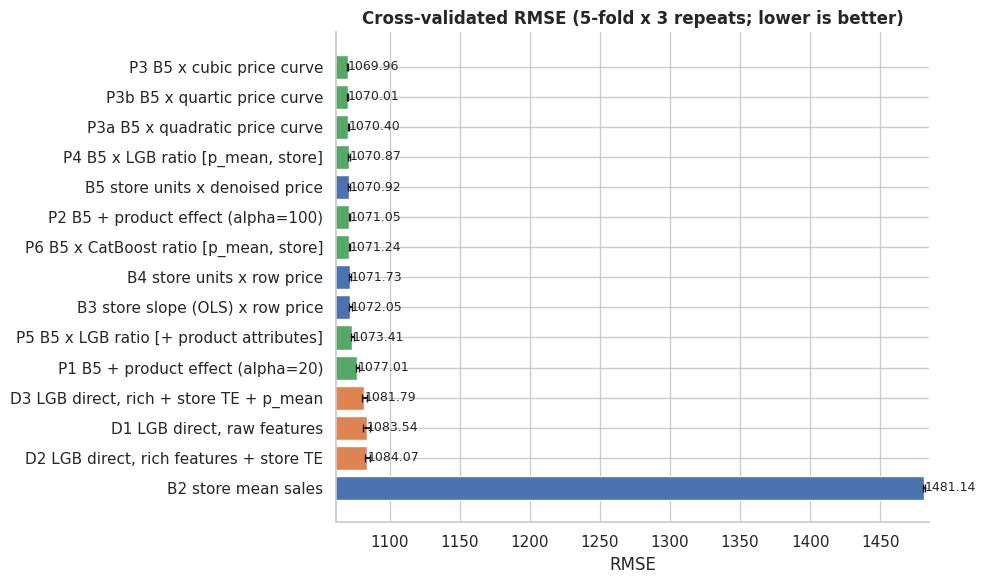

In [19]:
log = (pd.DataFrame([{k: v for k, v in r.items() if k not in ('oofs', 'test')} for r in RESULTS.values()])
         .sort_values('cv_mean').reset_index(drop=True))
display(log[['name', 'desc', 'cv_mean', 'cv_std', 'minutes']].round(2))

plot_log = log[log['name'] != 'B1 global mean'].sort_values('cv_mean', ascending=False)
colors = [PALETTE[0] if n.startswith('B') else PALETTE[1] if n.startswith('D') else PALETTE[2] for n in plot_log['name']]
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(plot_log['name'], plot_log['cv_mean'], xerr=plot_log['cv_std'], color=colors, capsize=3)
ax.set_xlim(plot_log['cv_mean'].min() - 8, plot_log['cv_mean'].max() + 4)
ax.set(title='Cross-validated RMSE (5-fold x 3 repeats; lower is better)', xlabel='RMSE')
for i, v in enumerate(plot_log['cv_mean']): ax.text(v + 0.3, i, f'{v:.2f}', va='center', fontsize=9)
plt.tight_layout(); plt.show()

### 5.2 Are the differences real? Paired bootstrap
A difference in CV of one or two points may be noise. Because all experiments use the same rows and folds, we can bootstrap the rows and look at the distribution of the *difference* in RMSE between two models.

In [20]:
def paired_bootstrap(a, b, n_boot=2000, seed=0):
    '''RMSE(a) - RMSE(b) with a 95% interval. Negative = a is better. Squared errors averaged over CV repeats.'''
    se_a = ((RESULTS[a]['oofs'] - y) ** 2).mean(0); se_b = ((RESULTS[b]['oofs'] - y) ** 2).mean(0)
    rng = np.random.default_rng(seed)
    diffs = [np.sqrt(se_a[i].mean()) - np.sqrt(se_b[i].mean()) for i in (rng.integers(0, len(y), len(y)) for _ in range(n_boot))]
    return np.sqrt(se_a.mean()) - np.sqrt(se_b.mean()), *np.percentile(diffs, [2.5, 97.5]), np.mean(np.array(diffs) < 0)

pairs = [('B5 store units x denoised price', 'B4 store units x row price'),
         ('B4 store units x row price', 'B3 store slope (OLS) x row price'),
         ('D2 LGB direct, rich features + store TE', 'B5 store units x denoised price'),
         ('P1 B5 + product effect (alpha=20)', 'B5 store units x denoised price'),
         ('P5 B5 x LGB ratio [+ product attributes]', 'P4 B5 x LGB ratio [p_mean, store]'),
         ('P3 B5 x cubic price curve', 'B5 store units x denoised price'),
         ('P4 B5 x LGB ratio [p_mean, store]', 'D2 LGB direct, rich features + store TE')]
rows = []
for a, b in pairs:
    d, lo, hi, p = paired_bootstrap(a, b)
    rows.append({'model A': a, 'model B': b, 'RMSE(A) - RMSE(B)': d, '95% CI low': lo, '95% CI high': hi, 'P(A better)': p})
pd.DataFrame(rows).round(3)

,model A,model B,RMSE(A) - RMSE(B),95% CI low,95% CI high,P(A better)
0,B5 store units x denoised price,B4 store units x row price,-0.809,-2.255,0.608,0.871
1,B4 store units x row price,B3 store slope (OLS) x row price,-0.317,-1.567,0.861,0.692
2,"D2 LGB direct, rich features + store TE",B5 store units x denoised price,13.149,7.072,19.531,0.000
3,P1 B5 + product effect (alpha=20),B5 store units x denoised price,6.089,1.651,10.851,0.003
4,P5 B5 x LGB ratio [+ product attributes],"P4 B5 x LGB ratio [p_mean, store]",2.541,0.790,4.331,0.001
5,P3 B5 x cubic price curve,B5 store units x denoised price,-0.963,-3.104,1.290,0.788
6,"P4 B5 x LGB ratio [p_mean, store]","D2 LGB direct, rich features + store TE",-13.206,-18.801,-7.975,1.000


### 5.3 What the experiments say
* **Denoising price helps, cheaply and for a clear reason.**
  * B5 beats B4 by 0.8 RMSE, better in 87% of bootstrap samples.
  * The same change improves the direct GBDT by 2.3 RMSE (D3 vs D2).
  * Using mean units rather than an OLS slope for store throughput is another small, consistent gain (B4 vs B3).
* **Direct gradient boosting on `total_sales` loses to a 10-parameter formula.**
  * D1–D3 score 1082–1084, which is 11–13 RMSE *worse* than B5. The paired 95% interval (+7.1 to +19.5) excludes zero.
  * The reason: the trees must rebuild the smooth price × store multiplication out of step functions, and they spend splits on noise columns.
  * The ~1076 CV reported for earlier versions came from early stopping on the validation fold, which flatters the score. Under the honest protocol used here, the same approach scores ~1084.
* **Product identity hurts.**
  * A lightly shrunk product effect (P1) is 6.1 RMSE worse (CI +1.7 to +10.9).
  * With strong shrinkage (P2) it collapses back to B5.
  * Both results confirm Q7.
* **Product attributes hurt, even as a small correction.** P5 is 2.5 RMSE worse than P4 (CI +0.8 to +4.3).
* **A gentle price-shape correction is the only addition that helps.**
  * The cubic curve P3 improves on B5 by ~1.0 RMSE and wins in **all three CV repeats**.
  * On its own that gain is not statistically conclusive (79% of bootstrap samples).
  * It is kept because it costs only 4 parameters and makes sense: mid-to-high-priced products sell slightly above the store average, and the most expensive ones slightly below (Section 7.2).
* **The curve is not sensitive to its exact form.** Quadratic (P3a) and quartic (P3b) versions land within ~0.5 RMSE of the cubic, so the choice of degree is not being tuned to noise.

## 6. How low can the RMSE go?
Before spending more effort, it is worth estimating the **irreducible error** — the part of the RMSE that no model using these columns can remove — and how much the **public leaderboard** moves by pure chance.

In [21]:
# 6.1 How much signal could still be left? Use the variance decomposition from Q7.
# The only candidate source of extra signal is a product-level effect. Even an ORACLE that knew every product's true
# effect exactly could only remove  E[base^2] * Var(product effect)  from the MSE.
base_oofs = RESULTS['B5 store units x denoised price']['oofs']
mse_b5 = np.mean([np.mean((y - o) ** 2) for o in base_oofs])
mean_base_sq = np.mean(base_oofs.mean(0) ** 2)
product_var = max(observed_between - expected_from_noise, 0)
rows_per_product_in_fold = len(eda) / eda['product_code'].nunique() * (CFG['n_splits'] - 1) / CFG['n_splits']
reliability = product_var / (product_var + within_var / rows_per_product_in_fold)   # how well ~3.5 rows can estimate it

oracle = np.sqrt(mse_b5 - mean_base_sq * product_var)
realistic = np.sqrt(mse_b5 - mean_base_sq * product_var * reliability)
best_name = log.iloc[0]['name']
print(f'B5 physical baseline CV                       : {np.sqrt(mse_b5):,.1f}')
print(f'Oracle lower bound (true product effects known): {oracle:,.1f}')
print(f'Best achievable with ~{rows_per_product_in_fold:.1f} rows per product   : {realistic:,.1f}  (reliability of a product estimate = {reliability:.2f})')
print(f'Best model in the experiments ({best_name}): {log.iloc[0].cv_mean:,.2f}')

B5 physical baseline CV                       : 1,070.9
Oracle lower bound (true product effects known): 1,053.3
Best achievable with ~3.5 rows per product   : 1,069.3  (reliability of a product estimate = 0.09)
Best model in the experiments (P3 B5 x cubic price curve): 1,069.96


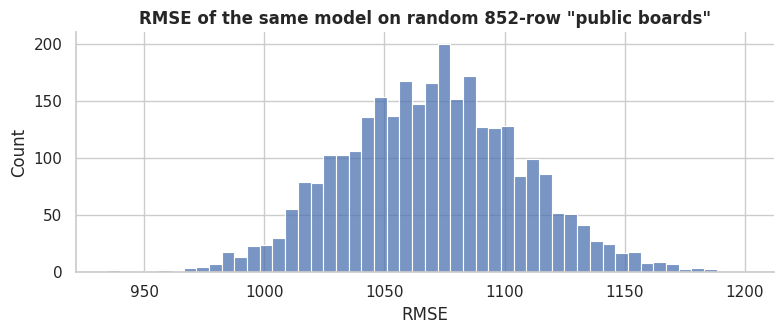

Public-board RMSE for an identical model: std 37.4, 90% range 1011–1132
Largest CV gap between the top-5 models: 0.96


In [22]:
# 6.2 How much does the public leaderboard move by luck? Score random test-sized halves of our OOF predictions.
oof_best = RESULTS[best_name]['oofs'].mean(0)
rng = np.random.default_rng(CFG['seed'])
n_public = len(test_df) // 2
pub = np.array([rmse(y[i], oof_best[i]) for i in (rng.choice(len(y), n_public, replace=False) for _ in range(3000))])

fig, ax = plt.subplots(figsize=(8, 3.5))
sns.histplot(pub, bins=50, ax=ax, color=PALETTE[0])
ax.set(title=f'RMSE of the same model on random {n_public}-row "public boards"', xlabel='RMSE')
plt.tight_layout(); plt.show()
print(f'Public-board RMSE for an identical model: std {pub.std():.1f}, 90% range {np.percentile(pub, 5):.0f}–{np.percentile(pub, 95):.0f}')
print(f'Largest CV gap between the top-5 models: {log.cv_mean.iloc[4] - log.cv_mean.iloc[0]:.2f}')

**Reading Section 6.** The only place extra signal could still hide is a product-level effect.
* Even an **oracle** that knew every product's true effect could reach ~1053 at best.
* With only ~3.5 training rows per product inside a fold, the realistic limit is **~1069**.
* The final model's 1069.96 is therefore within about one RMSE point of what this data allows.

At the same time, the public board moves an identical model by ±37 RMSE. Small differences between top leaderboard entries are mostly luck, and the private board will reshuffle them. This is why every choice in this notebook was made on repeated cross-validation.

## 7. Final model
### 7.1 Model selection
The candidates were all scored on identical folds in Section 5, so no refitting is needed to compare them: the physical baseline (B5), the cubic price curve (P3), the two tree-based corrections (P4, P6) and their equal-weight average.

**Rule:** take the lowest CV mean, but if the 4-parameter cubic model is within one CV standard deviation of the best, prefer it: fewer parameters means less risk on the private leaderboard. The best structurally different candidate is kept as a second submission. The chosen model is then **refit on the full training set** for the final predictions.

In [23]:
PARAMETRIC = 'P3 B5 x cubic price curve'
parts = [PARAMETRIC, 'P4 B5 x LGB ratio [p_mean, store]', 'P6 B5 x CatBoost ratio [p_mean, store]']
BLEND = 'F equal-weight blend (P3 + P4 + P6)'
blend_oofs = np.mean([RESULTS[p]['oofs'] for p in parts], axis=0)
blend_scores = [rmse(y, o) for o in blend_oofs]
RESULTS[BLEND] = dict(name=BLEND, desc='equal-weight average of P3, P4, P6', cv_mean=np.mean(blend_scores),
                      cv_std=np.std(blend_scores), oofs=blend_oofs, minutes=0,
                      test=np.mean([RESULTS[p]['test'] for p in parts], axis=0))

cands = ['B5 store units x denoised price', *parts, BLEND]
sel = pd.DataFrame([{'model': c, 'cv_mean': RESULTS[c]['cv_mean'], 'cv_std': RESULTS[c]['cv_std'],
                     **{f'repeat_{r}': rmse(y, RESULTS[c]['oofs'][r]) for r in range(CFG['n_repeats'])}}
                    for c in cands]).sort_values('cv_mean').reset_index(drop=True)
display(sel.round(2))

best = sel.iloc[0]
FINAL_NAME = PARAMETRIC if RESULTS[PARAMETRIC]['cv_mean'] <= best.cv_mean + best.cv_std else best.model
HEDGE_NAME = BLEND if FINAL_NAME != BLEND else PARAMETRIC
print(f'Selected final model : {FINAL_NAME}')
print(f'Second submission    : {HEDGE_NAME}')

w, _ = nnls(np.column_stack([RESULTS[p]['oofs'].mean(0) for p in parts]), y)
print('\nNNLS weights (diagnostic only):', dict(zip(['P3', 'P4', 'P6'], np.round(w, 3))))
print('Correlation between the three OOF predictions:')
display(pd.DataFrame({p[:2]: RESULTS[p]['oofs'].mean(0) for p in parts}).corr().round(4))

for ref in ['D2 LGB direct, rich features + store TE', 'B5 store units x denoised price']:
    d, lo, hi, p = paired_bootstrap(FINAL_NAME, ref)
    print(f'{FINAL_NAME} vs {ref}: {d:+.2f} RMSE (95% CI {lo:+.2f} to {hi:+.2f}; better in {p:.0%} of bootstrap samples)')

# Final predictions: refit the selected model on 100% of the training data
final_oof = RESULTS[FINAL_NAME]['oofs'].mean(0)
if FINAL_NAME == PARAMETRIC:
    final_test = make_poly(3)(train_df, y, [test_df], seed=CFG['seed'])[0]
else:
    final_test = RESULTS[FINAL_NAME]['test']
final_test = np.clip(final_test, 0, None)
print(f"\nFull-data refit vs average of the 15 fold models: correlation "
      f"{np.corrcoef(final_test, RESULTS[FINAL_NAME]['test'])[0, 1]:.5f}, mean abs difference ₦{np.abs(final_test - RESULTS[FINAL_NAME]['test']).mean():.2f}")

,model,cv_mean,cv_std,repeat_0,repeat_1,repeat_2
0,P3 B5 x cubic price curve,"1,069.960",0.400,"1,070.120","1,069.400","1,070.350"
1,F equal-weight blend (P3 + P4 + P6),"1,070.300",0.300,"1,070.260","1,069.960","1,070.700"
2,"P4 B5 x LGB ratio [p_mean, store]","1,070.870",0.650,"1,070.760","1,070.130","1,071.710"
3,B5 store units x denoised price,"1,070.920",0.460,"1,071.140","1,070.280","1,071.350"
4,"P6 B5 x CatBoost ratio [p_mean, store]","1,071.240",0.320,"1,070.810","1,071.580","1,071.330"


Selected final model : P3 B5 x cubic price curve
Second submission    : F equal-weight blend (P3 + P4 + P6)

NNLS weights (diagnostic only): {'P3': np.float64(0.934), 'P4': np.float64(0.047), 'P6': np.float64(0.019)}
Correlation between the three OOF predictions:


,P3,P4,P6
P3,1.000,1.000,0.999
P4,1.000,1.000,1.000
P6,0.999,1.000,1.000


P3 B5 x cubic price curve vs D2 LGB direct, rich features + store TE: -14.11 RMSE (95% CI -19.82 to -8.69; better in 100% of bootstrap samples)


P3 B5 x cubic price curve vs B5 store units x denoised price: -0.96 RMSE (95% CI -3.10 to +1.29; better in 79% of bootstrap samples)

Full-data refit vs average of the 15 fold models: correlation 1.00000, mean abs difference ₦0.11


### 7.2 What the model has learned (interpretation)
The final model is small enough to read directly: one throughput number per store, and one price-response curve.

,store_code,store_format,store_location_tier,rows,units_per_product,relative_to_corner_shops
0,STORE-7WS,Flagship Hypermarket,Tier_3,748,26.410,10.880
2,STORE-9RG,Standard Supermarket,Tier_2,752,17.130,7.060
1,STORE-89Z,Standard Supermarket,Tier_1,728,16.810,6.930
7,STORE-OYG,Standard Supermarket,Tier_2,744,16.660,6.860
9,STORE-YLW,Standard Supermarket,Tier_1,754,16.090,6.630
3,STORE-AGY,Standard Supermarket,Tier_3,748,15.950,6.570
4,STORE-DKU,Standard Supermarket,Tier_2,736,15.660,6.450
5,STORE-HL7,Superstore,Tier_3,742,13.850,5.710
8,STORE-T5G,Corner Shop,Tier_1,427,2.460,1.010
6,STORE-JOR,Corner Shop,Tier_3,439,2.390,0.990


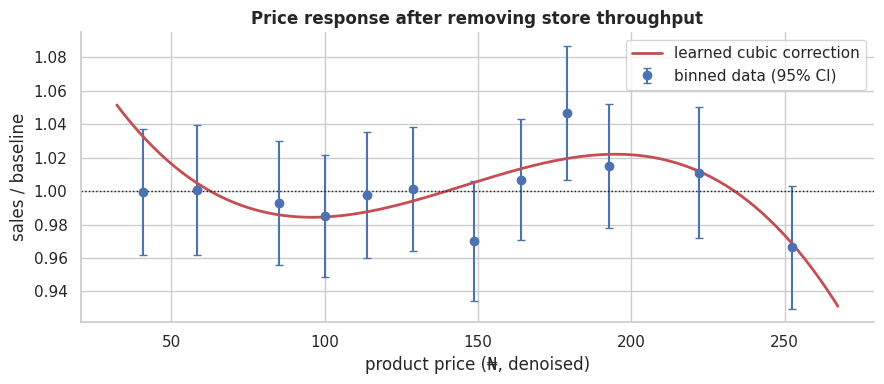

In [24]:
full_b = store_throughput(train_df, y)
interp = (train_df.groupby(['store_code', 'store_format', 'store_location_tier'], observed=True).size().rename('rows').reset_index()
          .assign(units_per_product=lambda d: d['store_code'].map(full_b).astype(float))
          .sort_values('units_per_product', ascending=False))
interp['relative_to_corner_shops'] = interp['units_per_product'] / interp.loc[interp.store_format == 'Corner Shop', 'units_per_product'].mean()
display(interp.round(2))

# Price-response curve: learned correction factor as a function of price (cubic model fitted on all data)
mu, sd = train_df['p_mean'].mean(), train_df['p_mean'].std()
base_full = baseline(train_df, full_b)
coef = np.linalg.lstsq(np.column_stack([base_full * ((train_df['p_mean'] - mu) / sd) ** k for k in range(4)]), y, rcond=None)[0]
grid = np.linspace(train_df['p_mean'].min(), train_df['p_mean'].max(), 200)
curve = np.column_stack([((grid - mu) / sd) ** k for k in range(4)]) @ coef

rel = y / base_full
bins = pd.qcut(train_df['p_mean'], 12)
emp = pd.DataFrame({'p': train_df['p_mean'], 'r': rel, 'w': base_full ** 2}).groupby(bins, observed=True).apply(
    lambda g: pd.Series({'p': g.p.mean(), 'r': np.average(g.r, weights=g.w), 'se': g.r.std() / np.sqrt(len(g))}))
fig, ax = plt.subplots(figsize=(9, 4))
ax.errorbar(emp['p'], emp['r'], yerr=1.96 * emp['se'], fmt='o', capsize=3, color=PALETTE[0], label='binned data (95% CI)')
ax.plot(grid, curve, color=PALETTE[3], lw=2, label='learned cubic correction')
ax.axhline(1, color='k', ls=':', lw=1)
ax.set(title='Price response after removing store throughput', xlabel='product price (₦, denoised)', ylabel='sales / baseline'); ax.legend()
plt.tight_layout(); plt.show()

## 7.3 Error analysis
Where is the model still wrong, and is the error structure consistent with pure noise?

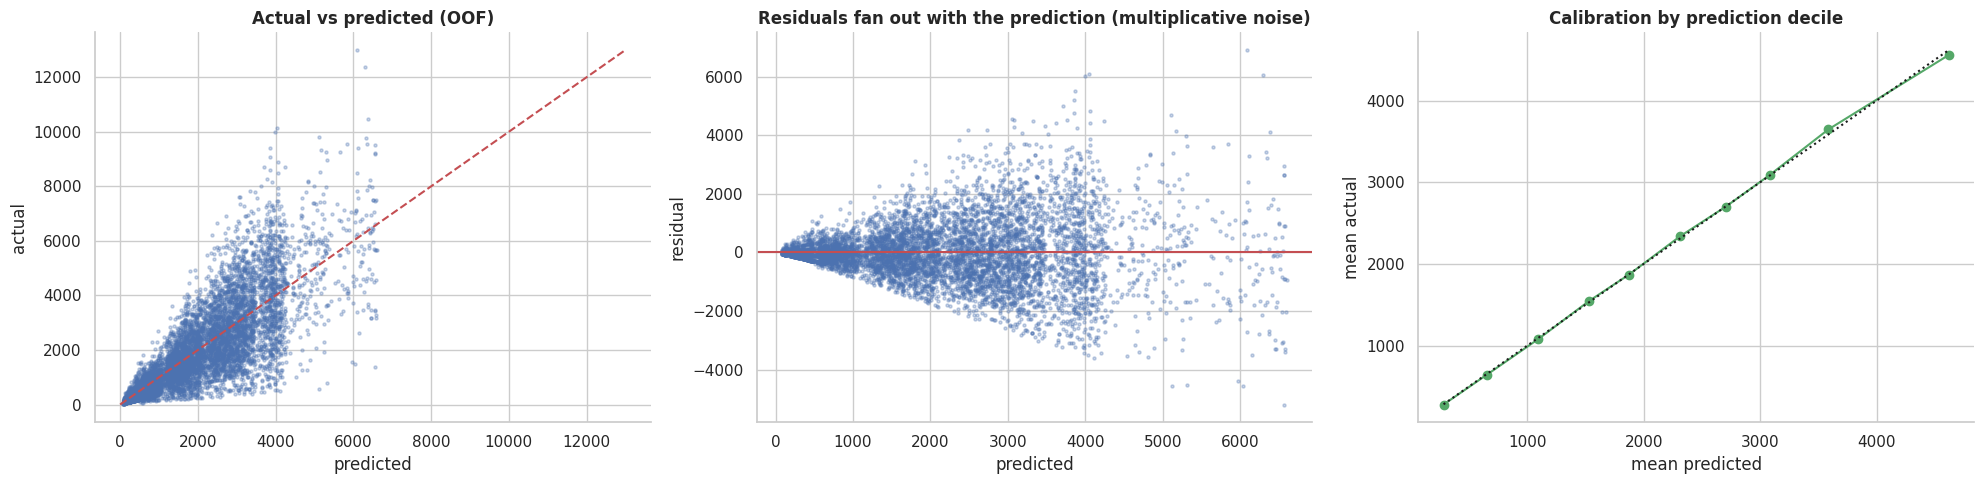

,rows,mean_actual,bias,rmse,share_of_squared_error_%
store_code,,,,,
STORE-7WS,748,"3,660.200",-29.300,"1,394.000",18.600
STORE-YLW,754,"2,254.000",-25.800,"1,151.300",12.800
STORE-OYG,744,"2,365.800",6.800,"1,143.300",12.500
STORE-9RG,752,"2,479.200",11.200,"1,109.900",11.900
STORE-DKU,736,"2,177.100",-11.900,"1,097.300",11.400
STORE-AGY,748,"2,254.900",21.800,"1,072.200",11.000
STORE-89Z,728,"2,365.900",9.700,"1,082.000",10.900
STORE-HL7,742,"1,971.700",31.300,"1,046.400",10.400
STORE-JOR,439,334.400,3.500,222.300,0.300


,rows,mean_actual,bias,rmse,share_of_squared_error_%
product_category,,,,,
Fruits And Vegetables,1006,"2,277.900",31.800,"1,101.000",15.600
Snack Foods,933,"2,223.800",-32.400,"1,101.600",14.500
Household,740,"2,292.500",-4.100,"1,094.500",11.400
Frozen Foods,675,"2,140.800",6.900,"1,055.600",9.600
Dairy,554,"2,238.300",-13.700,"1,159.500",9.500
Canned,517,"2,196.400",23.000,"1,014.900",6.800
Baking Goods,516,"1,943.400",-7.500,923.200,5.600
Soft Drinks,366,"1,967.400",0.400,"1,088.200",5.600
Health And Hygiene,412,"1,996.300",-4.300,993.900,5.200


In [25]:
err = train_df[['store_code', 'store_format', 'product_category', 'product_price', TARGET]].copy()
err['pred'] = final_oof
err['resid'] = err[TARGET] - err['pred']

fig, ax = plt.subplots(1, 3, figsize=(20, 5))
ax[0].scatter(err['pred'], err[TARGET], s=5, alpha=.3, color=PALETTE[0])
lim = err[TARGET].max(); ax[0].plot([0, lim], [0, lim], 'r--')
ax[0].set(title='Actual vs predicted (OOF)', xlabel='predicted', ylabel='actual')
ax[1].scatter(err['pred'], err['resid'], s=5, alpha=.3, color=PALETTE[0]); ax[1].axhline(0, color='r')
ax[1].set(title='Residuals fan out with the prediction (multiplicative noise)', xlabel='predicted', ylabel='residual')
dec = err.groupby(pd.qcut(err['pred'], 10), observed=True)[['pred', TARGET]].mean()
ax[2].plot(dec['pred'], dec[TARGET], marker='o', color=PALETTE[2]); ax[2].plot(dec['pred'], dec['pred'], 'k:')
ax[2].set(title='Calibration by prediction decile', xlabel='mean predicted', ylabel='mean actual')
plt.tight_layout(); plt.show()

for col in ['store_code', 'product_category']:
    t = err.groupby(col, observed=True).agg(rows=('resid', 'size'), mean_actual=(TARGET, 'mean'), bias=('resid', 'mean'),
                                            rmse=('resid', lambda s: np.sqrt((s ** 2).mean())))
    t['share_of_squared_error_%'] = err.groupby(col, observed=True)['resid'].apply(lambda s: (s ** 2).sum()) / (err['resid'] ** 2).sum() * 100
    display(t.sort_values('share_of_squared_error_%', ascending=False).round(1).head(10))

In [26]:
# Uncertainty for planners: because the noise is multiplicative, an interval is  prediction x [q_low, q_high]
# with q taken from the OOF ratio actual / predicted. Checked on the other CV repeats for honest coverage.
ratio = y / final_oof
q10, q90 = np.quantile(ratio, [0.10, 0.90])
cover = [np.mean((y >= RESULTS[FINAL_NAME]['oofs'][r] * q10) & (y <= RESULTS[FINAL_NAME]['oofs'][r] * q90)) for r in range(CFG['n_repeats'])]
print(f'80% prediction interval: prediction x [{q10:.2f}, {q90:.2f}]  (coverage across CV repeats: {np.mean(cover):.1%})')
print(f'Example: a forecast of ₦2,000 means actual sales between ₦{2000*q10:,.0f} and ₦{2000*q90:,.0f} four times out of five.')

80% prediction interval: prediction x [0.42, 1.61]  (coverage across CV repeats: 80.0%)
Example: a forecast of ₦2,000 means actual sales between ₦844 and ₦3,218 four times out of five.


**Reading the error analysis.** The error pattern matches unexplained noise rather than a missing driver.
* **Calibration:** mean predicted and mean actual sales agree across all ten prediction deciles.
* **Stores:** the bias for every store is under ₦32, about 1–2% of that store's mean, so no store is systematically over- or under-predicted.
* **Categories:** biases are at most ₦33, so no category needs its own treatment.
* **Where the error sits:** STORE-7WS carries 18.6% of the squared error from 11% of the rows, simply because its sales are the largest. The two corner shops together contribute 0.5%.
* **Uncertainty:** because the noise is multiplicative, the honest 80% prediction interval is roughly **0.42× to 1.61× the forecast**. That uncertainty belongs in any stock plan built on these forecasts.

# PREDICT
## 8. Submission

In [27]:
submission = pd.DataFrame({ID_COL: test_df[ID_COL].values, TARGET: final_test})

assert len(submission) == len(test_raw), 'row count mismatch'
assert (submission[ID_COL].values == test_raw[ID_COL].values).all(), 'id order mismatch'
assert submission[TARGET].notna().all() and (submission[TARGET] >= 0).all(), 'invalid predictions'

check = pd.DataFrame({'train actual': pd.Series(y).describe(), 'train OOF pred': pd.Series(final_oof).describe(),
                      'test pred': submission[TARGET].describe()})
display(check.round(1))
print('Mean prediction by store (test) vs mean actual by store (train):')
display(pd.DataFrame({'test_pred': submission.groupby(test_df['store_code'].values)[TARGET].mean(),
                      'train_actual': pd.Series(y).groupby(train_df['store_code'].values).mean()}).round(0))

submission.to_csv('submission.csv', index=False)
pd.DataFrame({ID_COL: test_df[ID_COL].values, TARGET: np.clip(RESULTS[HEDGE_NAME]['test'], 0, None)}).to_csv('submission_hedge.csv', index=False)
log_out = pd.DataFrame([{k: v for k, v in r.items() if k not in ('oofs', 'test')} for r in RESULTS.values()]).sort_values('cv_mean')
log_out.to_csv('experiment_log.csv', index=False)
print(f'Saved submission.csv ({FINAL_NAME}), submission_hedge.csv ({HEDGE_NAME}) and experiment_log.csv')
submission.head()

,train actual,train OOF pred,test pred
count,"6,818.000","6,818.000","1,705.000"
mean,"2,174.800","2,173.200","2,192.000"
std,"1,697.900","1,322.800","1,321.700"
min,32.700,81.500,84.800
25%,834.800,"1,071.400","1,196.300"
50%,"1,790.900","2,060.500","2,051.000"
75%,"3,092.600","3,083.100","3,106.900"
max,"12,996.800","6,604.200","6,529.900"


Mean prediction by store (test) vs mean actual by store (train):


,test_pred,train_actual
STORE-7WS,"3,740.000","3,660.000"
STORE-89Z,"2,369.000","2,366.000"
STORE-9RG,"2,388.000","2,479.000"
STORE-AGY,"2,350.000","2,255.000"
STORE-DKU,"2,279.000","2,177.000"
STORE-HL7,"2,051.000","1,972.000"
STORE-JOR,361.000,334.000
STORE-OYG,"2,177.000","2,366.000"
STORE-T5G,365.000,338.000
STORE-YLW,"2,307.000","2,254.000"


Saved submission.csv (P3 B5 x cubic price curve), submission_hedge.csv (F equal-weight blend (P3 + P4 + P6)) and experiment_log.csv


,id,total_sales
0,row_00009,"2,781.763"
1,row_00015,"4,259.805"
2,row_00019,"2,917.022"
3,row_00020,"3,143.823"
4,row_00023,"2,540.345"


# COMMUNICATE
## 9. Conclusions
### What drives sales
Revenue is price × units, and **units are a property of the store**, above all its format.
* The flagship hypermarket sells ~11× as many units per product as a corner shop.
* Among standard supermarkets, units per product barely change with location tier or store size.
* Once store and price are known, product attributes add no reliable information.

### What worked (honest CV, 5-fold × 3 repeats)
| Step | CV RMSE | Change |
|---|---|---|
| Global mean | 1697.9 | — |
| Store mean sales | 1481.1 | −216.8 |
| Store units × listed price | 1071.7 | −409.4 |
| … with denoised price (`p_mean`) | 1070.9 | −0.8 |
| … × cubic price curve (**final**) | 1070.0 | −1.0 |

### What did not work
* Direct GBDTs on 10–20 engineered features: 11–14 RMSE worse than the formula.
* Product target encoding: worse, and neutral only when shrunk to nothing.
* Adding product attributes to the correction model: 2.5 RMSE worse.
* Price-curve variants (quadratic, quartic, ridge-penalised, separate curves per store format): no gain over the cubic.
* Heavier ensembles: the tree learners correlate > 0.999 with the cubic model and do not improve on it.

### Recommendations for DSN Mart
1. **Treat store format as the main lever for volume.** Moving a standard supermarket to flagship-level throughput (~16 → ~26 units per product) is worth far more than any product-level change this data can detect.
   * Caveat: there are only 10 stores and this is observational data, so treat this as a strong hypothesis to validate, not a proven causal effect.
2. **Don't rely on location tier or store size alone for investment decisions.** Standard supermarkets in Tier 1, 2 and 3 perform almost identically.
3. **Plan stock from a store baseline and keep safety buffers.** A reasonable forecast is *store units per product × price*. Actual sales then fall within about 0.42× to 1.61× of that forecast 80% of the time, so safety stock should scale with the forecast.
4. **Test shelf changes before rolling them out.** Shelf visibility shows no measurable link with units here. Reallocating display space is not supported by this data, so run a controlled in-store test first.
5. **Opening a new store:** the best available forecast is the average throughput of existing stores of the same format.

### Limitations
* A single snapshot with no time dimension, so there is no seasonality, trend or promotion effect to learn from.
* Only 10 stores, so store-level conclusions rest on 10 data points.
* About ±45% of the variation is unexplained. Something that drives sales, such as stock-outs, promotions or local demand, is not in the data.

### Next steps
* **For DSN Mart:** collect weekly sales, promotion flags, stock-out records and catchment demographics. Those are the most likely sources of the missing variation.
* **For the model:** with time-stamped data, a hierarchical model (store × product × week) would become worthwhile. On this snapshot, more model complexity only fits noise.

### Leaderboard history
| Version | Approach | CV RMSE | Public LB |
|---|---|---|---|
| v1 | 5-fold LightGBM baseline | 1096.0* | 1080.22 |
| v2 | Regularised LightGBM + CatBoost blend | 1077.3* | 1071.15 |
| v3 | LGB + CatBoost + XGB + store target encoding | 1076.2* | 1069.55 |
| v4 | Physical baseline anchor + multi-seed GBDT stack + tail multiplier | 1071.4* | 1069.05 |
| **v5** | **This notebook: store throughput × denoised price × cubic price curve** | **1069.96** (honest) | **1069.75** |

\* Earlier CV figures used early stopping and blend/multiplier tuning on the validation predictions, which makes them optimistic. They are not directly comparable with v5's leak-free CV.